# BUSINESS PROBLEM
- #### Credit card companies generate large volumes of customer financial and transaction data, making it difficult to identify high-value customers, risky financial behavior, and potential defaulters. Ineffective customer segmentation and poor risk assessment can lead to financial losses, increased defaults, fraud exposure, and reduced customer retention.
- #### This project aims to analyze customer demographics, spending patterns, credit utilization, repayment behavior, and transaction activity to identify valuable customer segments, evaluate financial risk, and support data-driven business decisions.

In [2]:
import pandas as pd
import numpy as np

df= pd.read_csv(r"C:\Users\DELL\Downloads\Credit_Card_Dataset.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_ID                   10000 non-null  object 
 1   Age                           10000 non-null  int64  
 2   Gender                        10000 non-null  object 
 3   Marital_Status                10000 non-null  object 
 4   Education_Level               10000 non-null  object 
 5   Employment_Status             10000 non-null  object 
 6   Annual_Income                 10000 non-null  int64  
 7   Credit_Score                  10000 non-null  int64  
 8   Number_of_Credit_Lines        10000 non-null  int64  
 9   Credit_Utilization_Ratio      10000 non-null  float64
 10  Debt_To_Income_Ratio          10000 non-null  float64
 11  Number_of_Late_Payments       10000 non-null  int64  
 12  Tenure_in_Years               10000 non-null  int64  
 13  To

In [4]:
df.isna().sum()

Customer_ID                     0
Age                             0
Gender                          0
Marital_Status                  0
Education_Level                 0
Employment_Status               0
Annual_Income                   0
Credit_Score                    0
Number_of_Credit_Lines          0
Credit_Utilization_Ratio        0
Debt_To_Income_Ratio            0
Number_of_Late_Payments         0
Tenure_in_Years                 0
Total_Transactions_Last_Year    0
Total_Spend_Last_Year           0
Defaulted                       0
CLV                             0
Total_Transactions              0
Avg_Transaction_Amount          0
Max_Transaction_Amount          0
Min_Transaction_Amount          0
Fraud_Transactions              0
Unique_Merchant_Categories      0
Unique_Transaction_Cities       0
dtype: int64

In [5]:
df.duplicated().any()

np.False_

In [6]:
df.describe()

,Age,Annual_Income,Credit_Score,Number_of_Credit_Lines,Credit_Utilization_Ratio,Debt_To_Income_Ratio,Number_of_Late_Payments,Tenure_in_Years,Total_Transactions_Last_Year,Total_Spend_Last_Year,Defaulted,CLV,Total_Transactions,Avg_Transaction_Amount,Max_Transaction_Amount,Min_Transaction_Amount,Fraud_Transactions,Unique_Merchant_Categories,Unique_Transaction_Cities
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.151500,60266.917400,648.739800,4.997100,0.499742,0.496404,1.005100,14.374100,103.678300,15039.833800,0.345100,45048.057900,20.000000,499.684392,1788.102222,26.028774,0.329200,8.649500,12.648800
std,14.083223,15109.825468,50.082106,2.600494,0.291170,0.288152,1.009146,8.709129,54.562023,6544.226127,0.475425,27257.520172,4.421058,114.031482,647.904025,27.730068,0.568735,1.079058,2.151539
min,21.000000,576.000000,469.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.000000,201.000000,0.000000,990.000000,6.000000,189.168235,414.200000,0.000000,0.000000,4.000000,4.000000
25%,33.000000,50161.750000,615.000000,3.000000,0.240000,0.250000,0.000000,7.000000,56.000000,9772.750000,0.000000,24213.000000,17.000000,419.651364,1333.022500,7.290000,0.000000,8.000000,11.000000
50%,45.000000,60167.500000,649.000000,5.000000,0.500000,0.500000,1.000000,14.000000,103.000000,14263.500000,0.000000,38549.500000,20.000000,490.280000,1676.360000,17.500000,0.000000,9.000000,13.000000
75%,57.000000,70355.250000,683.000000,7.000000,0.760000,0.740000,2.000000,22.000000,151.000000,19420.500000,1.000000,60312.500000,23.000000,568.366161,2124.622500,35.672500,1.000000,9.000000,14.000000
max,69.000000,112128.000000,832.000000,9.000000,1.000000,1.000000,7.000000,29.000000,199.000000,41128.000000,1.000000,170968.000000,37.000000,1172.910833,7096.240000,376.010000,5.000000,10.000000,19.000000


In [7]:
Total_Income=df['Annual_Income'].sum()
print(Total_Income)

602669174


## Hypotheses test
### Objective
- #### Is credit score responsible for default of customer
### Hypotheses
- #### H0 - Credit score has no role in default of customer
- #### H1 - Credit score has significant role in default of customers

In [8]:
default=df[df["Defaulted"]==1]["Credit_Score"]
non_default=df[df["Defaulted"]==0]["Credit_Score"]

In [9]:
from scipy .stats import ttest_ind

In [10]:
t_stat, p_value = ttest_ind(default,non_default, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -3.021905010644076
P-value: 0.0025211465743281217


In [11]:
alpha=0.05 #Assume
if p_value <= alpha:
    print("Reject H0: Credit score has significant role in default of customers")
else:
    print("Fail to Reject H0: Credit score has no role in default of customer")

Reject H0: Credit score has significant role in default of customers


## Hypotheses test
### Objective
- #### Is number of late payement increase the risk of default
### Hypotheses
- #### H0 - Late payment does not affect risk of default
- #### H1 - Late payment significantly affect risk of default

In [12]:
default=df[df["Defaulted"]==1]["Number_of_Late_Payments"]
non_default=df[df["Defaulted"]==0]["Number_of_Late_Payments"]

In [13]:
alpha=0.05 #Assume
if p_value <= alpha:
    print("Reject H0: Late payment significantly affect risk of default")
else:
    print("Fail to Reject H0: Late payment does not affect risk of default")

Reject H0: Late payment significantly affect risk of default


In [14]:
alpha=0.05 #Assume
if p_value <= alpha:
    print("Reject H0: Late payment significantly affect risk of default")
else:
    print("Fail to Reject H0: Late payment does not affect risk of default")

Reject H0: Late payment significantly affect risk of default


In [15]:
customers_default= df.groupby('Defaulted')['Number_of_Late_Payments'].count()
print(customers_default)

Defaulted
0    6549
1    3451
Name: Number_of_Late_Payments, dtype: int64


## Hypotheses test
### Objective
- #### Is Credit Utilization increase the risk of default
### Hypotheses
- #### H0 - Credit Utilization does not increase the risk of default
- #### H1- Credit Utilization increase the risk of default

In [16]:
default=df[df["Defaulted"]==1]["Credit_Utilization_Ratio"]
non_default=df[df["Defaulted"]==0]["Credit_Utilization_Ratio"]

In [17]:
t_stat, p_value = ttest_ind(default,non_default, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 32.14317106427778
P-value: 1.988087241438661e-212


In [18]:
alpha=0.05 #Assume
if p_value <= alpha:
    print("Reject H0: Credit Utilization increase the risk of default")
else:
    print("Fail to Reject H0: Credit Utilization does not increase the risk of default")

Reject H0: Credit Utilization increase the risk of default


## Business Insight
- #### Banks should closely monitor low credit score customers before approving credit products.
- #### Repayment behavior is a critical predictor of financial risk.
- #### High utilization customers may be financially stressed and require stricter monitoring.

In [19]:
import seaborn as sns
import matplotlib.pyplot as mlt

<Axes: xlabel='Defaulted', ylabel='count'>

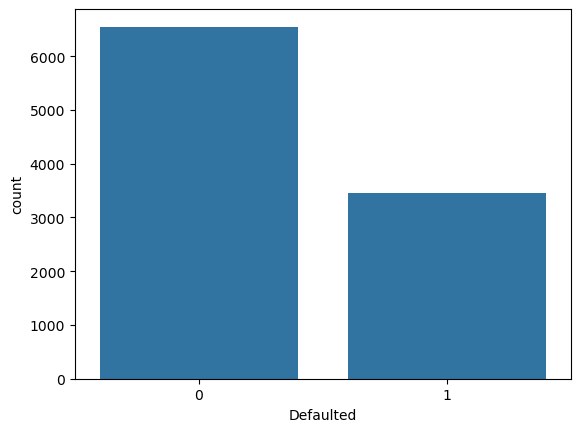

In [20]:
sns.countplot(x='Defaulted', data=df)

<Axes: xlabel='Defaulted', ylabel='Credit_Score'>

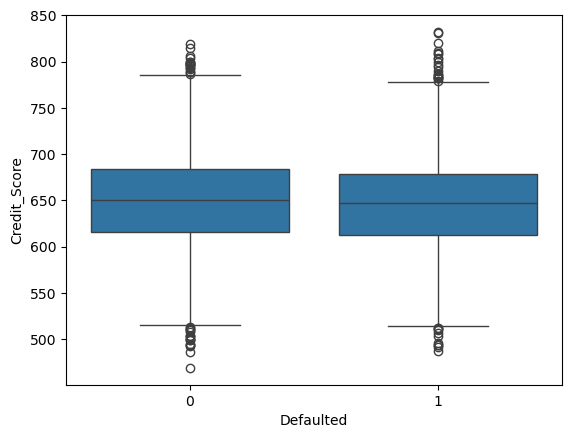

In [21]:
sns.boxplot(x='Defaulted', y='Credit_Score', data=df)

In [22]:
from sqlalchemy import create_engine


user = 'root'
password = 'Your Password'
host = 'localhost'  
port = 3306
database = 'bank'


engine = create_engine(f'mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}')

In [23]:
df.to_sql("bank_analysis", engine, if_exists="replace", index=False)

print("Data uploaded successfully!")

Data uploaded successfully!
